In [ ]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [ ]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SuperFOVi', 'SyntheticBanding']
model_dir = "D:/DeepSSFP/block9_phantom/"
model_name="block9_phantom"


In [8]:
slices = 500
tissue_parameters = {
    0: ('none', 0, 0, 0),
    1: ('fat', 0.350, 0.130, 0),
    2: ('bone marrow', 0.370, 0.05, 0),
    3: ('liver', 0.8, 0.04, 0),
    4: ('white matter', 1.0, 0.08, 0),
    5: ('myocardium', 1.150, 0.045, 0),
    6: ('vessels', 1.2, 0.05, 0),   
    7: ('gray matter', 1.3, 0.110, 0),
    8: ('muscle', 1.4, 0.030, 0),
    9: ('CSF', 4.0, 1.0, 0)
}

dataset = mssfp.generate_ssfp_dataset(
    phantom_type='block', 
    slices=slices, 
    shape=128, 
    ids=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    tissues = tissue_parameters,
    npcs=4, 
    f=500, 
    alpha=np.deg2rad(40), 
    sigma=0.001, 
    useRotate=True, 
    useDeform=True,
    rotation=90,
    fn_offset=250
)


Generating phantom...
Generating SSFP dataset...
Dataset complete.
Dataset shape: (500, 128, 128, 4)


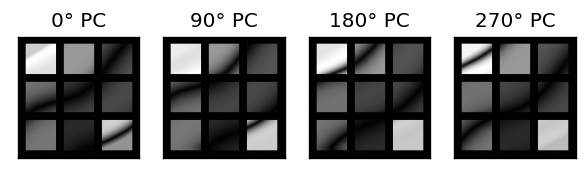

In [9]:
mssfp.plot_dataset(dataset['M'], slice=1, dpi=120)

Dataset: mode:BandRemoval:4, size:500 height:128 width:128 cin:8 cout:2 ratio:0.8 dtype: float64, float64


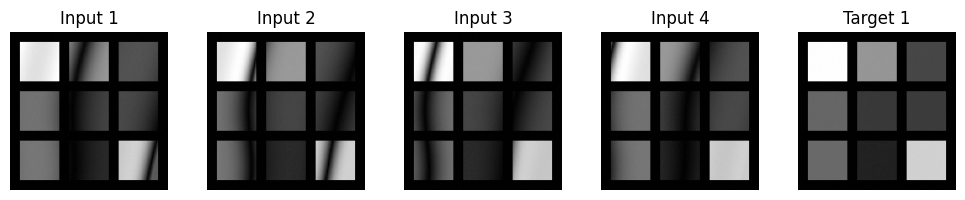

Dataset: mode:BandRemoval:2, size:500 height:128 width:128 cin:4 cout:2 ratio:0.8 dtype: float64, float64


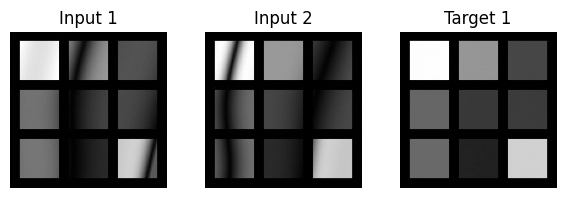

Dataset: mode:SyntheticBanding, size:500 height:128 width:128 cin:4 cout:4 ratio:0.8 dtype: float64, float64


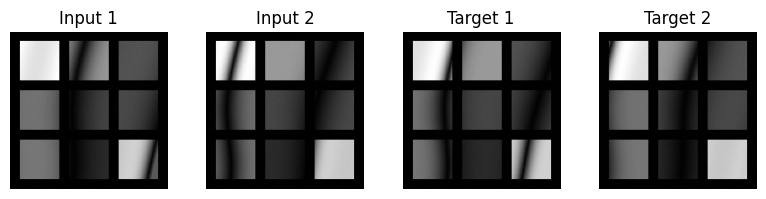

Dataset: mode:SuperFOV, size:500 height:128 width:128 cin:2 cout:2 ratio:0.8 dtype: float64, float64


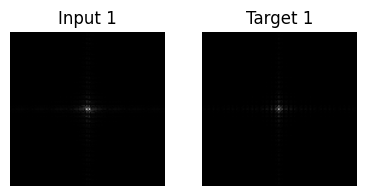

Dataset: mode:SuperFOVi, size:500 height:128 width:128 cin:2 cout:2 ratio:0.8 dtype: float64, float64


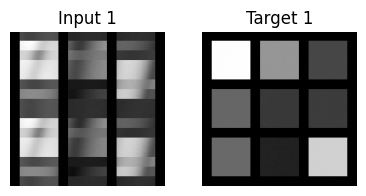

In [10]:
mode = deepssfp.dataset.DataMode.BandRemoval4.value
ds = deepssfp.dataset.Dataset(mode, input_data=dataset['M'])
deepssfp.visualize_images(input_images=ds.x_test, target_images=ds.y_test, index=[14])

mode = deepssfp.dataset.DataMode.BandRemoval2.value
ds = deepssfp.dataset.Dataset(mode, input_data=dataset['M'])
deepssfp.visualize_images(input_images=ds.x_test, target_images=ds.y_test, index=[14])

mode = deepssfp.dataset.DataMode.SyntheticBanding.value
ds = deepssfp.dataset.Dataset(mode, input_data=dataset['M'])
deepssfp.visualize_images(input_images=ds.x_test, target_images=ds.y_test, index=[14])

mode = deepssfp.dataset.DataMode.SuperFOV.value
ds = deepssfp.dataset.Dataset(mode, input_data=dataset['M'])
deepssfp.visualize_images(input_images=ds.x_test, target_images=ds.y_test, index=[14])

mode = deepssfp.dataset.DataMode.SuperFOVi.value
ds = deepssfp.dataset.Dataset(mode, input_data=dataset['M'])
deepssfp.visualize_images(input_images=ds.x_test, target_images=ds.y_test, index=[14])